In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

patients = pd.read_csv("Dataset/patients.csv")
conditions = pd.read_csv("Dataset/conditions.csv")
observations = pd.read_csv("Dataset/observations.csv")
medications = pd.read_csv("Dataset/medications.csv")

In [2]:
#Finding age 
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
patients['AGE'] = 2026 - patients['BIRTHDATE'].dt.year

#forming a mdf = master dataframe
mdf = patients[['Id', 'AGE', 'GENDER', 'RACE', 'ETHNICITY', 'INCOME', 'HEALTHCARE_EXPENSES']].copy()
mdf.rename(columns={'Id': 'PATIENT_ID'}, inplace=True)
mdf.sample(15)

,PATIENT_ID,AGE,GENDER,RACE,ETHNICITY,INCOME,HEALTHCARE_EXPENSES
20,67e00c58-d6fe-5f0d-400e-9b89fc52d916,34,M,white,nonhispanic,892231,49847.56
108,80d8aaa2-ef65-5f53-3a31-a3823d7e0151,13,F,white,nonhispanic,46108,43080.82
59,f871e4dc-ea49-ae10-f488-cabc2a581bc3,18,F,white,nonhispanic,43939,38633.91
23,cc0f3cdb-1882-1d37-47ce-2ce320c85d0a,33,M,white,nonhispanic,38044,85324.28
66,ba696827-b735-e09f-e5f5-f15037dc9701,44,M,white,nonhispanic,28084,75041.66
74,2a2bd415-e59e-ae60-2cc3-39f5c9e66025,45,F,white,nonhispanic,172991,208008.67
44,56cb71e6-0d69-d211-3b19-73e43d75dc26,37,F,white,nonhispanic,752820,151474.30
31,03112dec-e648-dc9c-2f26-3d47e1266ded,74,F,other,hispanic,129464,185690.91
45,a08c7d55-8400-6d5d-908f-13a33e8214c0,60,F,white,nonhispanic,68569,837015.18
52,94e1acbd-dd9c-977c-61c7-4bf24f8401fe,72,M,white,nonhispanic,13910,22412.45


In [3]:
mdf["PATIENT_ID"].duplicated().sum()

0

In [4]:
# Create patient-condition mapping
patient_conditions = (
    conditions.groupby("PATIENT")["DESCRIPTION"]
    .apply(lambda x: " | ".join(x.unique()))
    .reset_index()
)

# Rename columns
patient_conditions.columns = ["PATIENT_ID", "CONDITIONS"]

# Merge once
mdf = mdf.merge(
    patient_conditions,
    on="PATIENT_ID",
    how="left"
)

mdf.head()

,PATIENT_ID,AGE,GENDER,RACE,ETHNICITY,INCOME,HEALTHCARE_EXPENSES,CONDITIONS
0,69af9fdb-6026-cf15-8110-60645be1a286,75,F,white,nonhispanic,53813,781858.42,Received higher education (finding) | Body mas...
1,e2b7d298-e3e5-8e5a-804c-a8342fdeb164,69,F,white,nonhispanic,109027,617728.28,Risk activity involvement (finding) | Received...
2,ca4f2fef-0fea-5cdb-314c-9d6689cfabb0,21,F,white,hispanic,125882,11148.62,Atopic dermatitis (disorder) | Chronic sinusit...
3,36a8268b-0e08-f9d6-6999-eca371aab83c,48,F,asian,nonhispanic,65255,739328.17,Adolescent idiopathic scoliosis (disorder) | C...
4,7bfad7bf-fbc0-2a68-6c37-b9351c1ec651,13,F,black,nonhispanic,136314,17836.60,Medication review due (situation) | Viral sinu...


In [10]:
# Convert dates
medications["START"] = pd.to_datetime(
    medications["START"],
    utc=True,
    errors="coerce"
)

medications["STOP"] = pd.to_datetime(
    medications["STOP"],
    utc=True,
    errors="coerce"
)

# For ongoing medications, use latest date in dataset
latest_date = medications["START"].max()

medications["STOP_FILLED"] = medications["STOP"].fillna(latest_date)

# Duration in days
medications["DURATION_DAYS"] = (
    medications["STOP_FILLED"] - medications["START"]
).dt.days

In [11]:
med_duration = medications[
    ["PATIENT", "DESCRIPTION", "DURATION_DAYS"]
].copy()

med_duration.head()

,PATIENT,DESCRIPTION,DURATION_DAYS
0,e2b7d298-e3e5-8e5a-804c-a8342fdeb164,Clopidogrel 75 MG Oral Tablet,6777
1,e2b7d298-e3e5-8e5a-804c-a8342fdeb164,Simvastatin 20 MG Oral Tablet,6777
2,ca4f2fef-0fea-5cdb-314c-9d6689cfabb0,Fexofenadine hydrochloride 30 MG Oral Tablet,7165
3,ca4f2fef-0fea-5cdb-314c-9d6689cfabb0,NDA020800 0.3 ML Epinephrine 1 MG/ML Auto-Inje...,7165
4,e2b7d298-e3e5-8e5a-804c-a8342fdeb164,24 HR metoprolol succinate 100 MG Extended Rel...,6777


In [16]:
med_duration = (
    med_duration.groupby(
        ["PATIENT", "DESCRIPTION"]
    )["DURATION_DAYS"]
    .sum()
    .reset_index()
)
med_pivot = med_duration.pivot(
    index="PATIENT",
    columns="DESCRIPTION",
    values="DURATION_DAYS"
)
med_pivot = med_pivot.fillna(0)

med_pivot.columns = [
    f"{col}_DURATION"
    for col in med_pivot.columns
]

In [18]:
med_pivot = med_pivot.reset_index()

med_pivot.rename(
    columns={"PATIENT": "PATIENT_ID"},
    inplace=True
)

mdf = mdf.merge(
    med_pivot,
    on="PATIENT_ID",
    how="left"
)

mdf.fillna(0, inplace=True)

mdf.sample(15)

,PATIENT_ID,AGE,GENDER,RACE,ETHNICITY,INCOME,HEALTHCARE_EXPENSES,CONDITIONS,0.25 ML Leuprolide Acetate 30 MG/ML Prefilled Syringe,1 ML DOCEtaxel 20 MG/ML Injection,...,valsartan 320 MG Oral Tablet_DURATION_y,{21 (ethinyl estradiol 0.03 MG / levonorgestrel 0.15 MG Oral Tablet) / 7 (inert ingredients 1 MG Oral Tablet) } Pack [Levora 0.15/30 28 Day]_DURATION_y,{24 (drospirenone 3 MG / ethinyl estradiol 0.02 MG Oral Tablet) / 4 (inert ingredients 1 MG Oral Tablet) } Pack [Yaz 28 Day]_DURATION_y,{28 (norethindrone 0.35 MG Oral Tablet) } Pack [Camila 28 Day]_DURATION_y,{28 (norethindrone 0.35 MG Oral Tablet) } Pack [Errin 28 Day]_DURATION_y,{28 (norethindrone 0.35 MG Oral Tablet) } Pack [Jolivette 28 Day]_DURATION_y,{5 (dienogest 2 MG / estradiol valerate 2 MG Oral Tablet) / 17 (dienogest 3 MG / estradiol valerate 2 MG Oral Tablet) / 2 (estradiol valerate 1 MG Oral Tablet) / 2 (estradiol valerate 3 MG Oral Tablet) / 2 (inert ingredients 1 MG Oral Tablet) } Pack [Natazia 28 Day]_DURATION_y,{5 (ethinyl estradiol 0.02 MG / norethindrone acetate 1 MG Oral Tablet) / 7 (ethinyl estradiol 0.03 MG / norethindrone acetate 1 MG Oral Tablet) / 9 (ethinyl estradiol 0.035 MG / norethindrone acetate 1 MG Oral Tablet) / 7 (ferrous fumarate 75 MG Oral Tablet) } Pack [Estrostep Fe 28 Day]_DURATION_y,{7 (ethinyl estradiol 0.01 MG Oral Tablet) / 84 (ethinyl estradiol 0.03 MG / levonorgestrel 0.15 MG Oral Tablet) } Pack [Seasonique]_DURATION_y,{7 (ethinyl estradiol 0.035 MG / norgestimate 0.18 MG Oral Tablet) / 7 (ethinyl estradiol 0.035 MG / norgestimate 0.215 MG Oral Tablet) / 7 (ethinyl estradiol 0.035 MG / norgestimate 0.25 MG Oral Tablet) / 7 (inert ingredients 1 MG Oral Tablet) } Pack [Trinessa 28 Day]_DURATION_y
54,2c490ba7-cbf7-e71b-5338-00dab01da70d,49,F,white,nonhispanic,139175,275368.09,History of appendectomy (situation) | Educated...,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75,ab3dc837-38ee-a41d-8850-8393bcb66ecc,56,M,white,nonhispanic,86826,138748.95,Received higher education (finding) | Body mas...,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81,c303f8a0-d9b7-709b-fbe2-57ed2b5732e2,110,M,white,hispanic,43389,229622.78,Serving in military service (finding) | Unempl...,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21,2f1e6b1d-7021-cc53-c632-9c4d4c767f0a,35,M,white,hispanic,87909,62301.87,Chronic intractable migraine without aura (dis...,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90,93551fec-62f7-db5d-e2d4-65cfedfa8f50,52,F,white,nonhispanic,93066,374151.17,Risk activity involvement (finding) | Only rec...,0.0,0.0,...,0.0,0.0,0.0,720.0,360.0,1080.0,0.0,0.0,0.0,0.0
76,aa7dcd69-9e2b-469d-dcb1-ba347449d75b,58,F,white,hispanic,69929,683836.47,Chronic sinusitis (disorder) | Risk activity i...,0.0,0.0,...,0.0,0.0,0.0,0.0,360.0,0.0,360.0,0.0,0.0,0.0
43,acfbc141-31a0-1b38-ca04-5d89b27de80c,49,F,white,nonhispanic,73371,711831.39,Chronic sinusitis (disorder) | Received higher...,0.0,0.0,...,0.0,0.0,0.0,212.0,720.0,360.0,0.0,0.0,0.0,0.0
98,e8e59dfb-b161-68ba-fffa-c6f535602f11,110,M,white,hispanic,43389,365845.26,Risk activity involvement (finding) | Loss of ...,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50,ddcc5268-1271-fe06-f7ee-1fe645fc1733,22,F,white,nonhispanic,82287,81560.87,Chronic sinusitis (disorder) | Perennial aller...,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,360.0,284.0,0.0,0.0,0.0
13,97effce1-107c-d064-5d72-aa16ae4a095c,64,F,white,nonhispanic,16109,22072.94,Educated to high school level (finding) | Lack...,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
print("Total patients:",
      medications["PATIENT"].nunique())

print("Patients with at least one reason:",
      reason_count.shape[0])

print("Patients with multiple reasons:",
      (reason_count > 1).sum())

Total patients: 108
Patients with at least one reason: 102
Patients with multiple reasons: 86


In [29]:
medications["REASONDESCRIPTION"].nunique()

35

In [30]:
# Create patient-level reason features
reason_ohe = pd.crosstab(
    medications["PATIENT"],
    medications["REASONDESCRIPTION"]
)

# Convert counts to 0/1
reason_ohe = (reason_ohe > 0).astype(int)

# Convert index to column
reason_ohe = reason_ohe.reset_index()

# Rename for merging
reason_ohe.rename(
    columns={"PATIENT": "PATIENT_ID"},
    inplace=True
)

# Merge with master dataframe
mdf = mdf.merge(
    reason_ohe,
    on="PATIENT_ID",
    how="left"
)

# Fill missing values
mdf.fillna(0, inplace=True)

print(mdf.shape)

(111, 452)


In [32]:
mdf

,PATIENT_ID,AGE,GENDER,RACE,ETHNICITY,INCOME,HEALTHCARE_EXPENSES,CONDITIONS,0.25 ML Leuprolide Acetate 30 MG/ML Prefilled Syringe,1 ML DOCEtaxel 20 MG/ML Injection,...,Osteoporosis (disorder),Overlapping malignant neoplasm of colon (disorder),Patient referral for dental care (procedure),Prediabetes (finding),Pyelonephritis (disorder),Sepsis (disorder),Septic shock (disorder),Sinusitis (disorder),Streptococcal sore throat (disorder),Viral sinusitis (disorder)
0,69af9fdb-6026-cf15-8110-60645be1a286,75,F,white,nonhispanic,53813,781858.42,Received higher education (finding) | Body mas...,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,e2b7d298-e3e5-8e5a-804c-a8342fdeb164,69,F,white,nonhispanic,109027,617728.28,Risk activity involvement (finding) | Received...,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ca4f2fef-0fea-5cdb-314c-9d6689cfabb0,21,F,white,hispanic,125882,11148.62,Atopic dermatitis (disorder) | Chronic sinusit...,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,36a8268b-0e08-f9d6-6999-eca371aab83c,48,F,asian,nonhispanic,65255,739328.17,Adolescent idiopathic scoliosis (disorder) | C...,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7bfad7bf-fbc0-2a68-6c37-b9351c1ec651,13,F,black,nonhispanic,136314,17836.60,Medication review due (situation) | Viral sinu...,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,e65474c7-e574-ecf3-472b-2a3430455d2d,59,M,white,nonhispanic,838762,160521.74,Educated to high school level (finding) | Tran...,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
107,25127bd5-f9aa-30d5-d3f9-c5c88e27d527,110,M,white,hispanic,43389,347008.30,Risk activity involvement (finding) | Received...,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108,80d8aaa2-ef65-5f53-3a31-a3823d7e0151,13,F,white,nonhispanic,46108,43080.82,Medication review due (situation) | Otitis med...,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
109,583ce668-85c2-9599-09bb-4c6d620a795d,71,F,white,nonhispanic,172333,292894.92,Risk activity involvement (finding) | Housing ...,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
mdf.columns

Index(['PATIENT_ID', 'AGE', 'GENDER', 'RACE', 'ETHNICITY', 'INCOME',
       'HEALTHCARE_EXPENSES', 'CONDITIONS',
       '0.25 ML Leuprolide Acetate 30 MG/ML Prefilled Syringe',
       '1 ML DOCEtaxel 20 MG/ML Injection',
       ...
       'Osteoporosis (disorder)',
       'Overlapping malignant neoplasm of colon (disorder)',
       'Patient referral for dental care (procedure)', 'Prediabetes (finding)',
       'Pyelonephritis (disorder)', 'Sepsis (disorder)',
       'Septic shock (disorder)', 'Sinusitis (disorder)',
       'Streptococcal sore throat (disorder)', 'Viral sinusitis (disorder)'],
      dtype='object', length=452)

In [41]:
feature_cols = mdf.columns[8:]  # skip basic demographic columns

feature_freq = (mdf[feature_cols] > 0).sum()

feature_freq.sort_values().head(20)
[x for x in mdf.columns if "_x" in x or "_y" in x]
sum("_x" in col or "_y" in col for col in mdf.columns)

272

In [42]:
# Remove all _x and _y columns
mdf = mdf.loc[
    :,
    ~mdf.columns.str.endswith(("_x", "_y"))
]

print(mdf.shape)

(111, 180)


In [43]:
zero_cols = mdf.columns[(mdf == 0).all()]

print("Zero columns:", len(zero_cols))

mdf = mdf.drop(columns=zero_cols)

print(mdf.shape)

Zero columns: 0
(111, 180)


In [44]:
print("Rows:", mdf.shape[0])
print("Columns:", mdf.shape[1])

mdf.columns[:20]

Rows: 111
Columns: 180


Index(['PATIENT_ID', 'AGE', 'GENDER', 'RACE', 'ETHNICITY', 'INCOME',
       'HEALTHCARE_EXPENSES', 'CONDITIONS',
       '0.25 ML Leuprolide Acetate 30 MG/ML Prefilled Syringe',
       '1 ML DOCEtaxel 20 MG/ML Injection',
       '1 ML Epoetin Alfa 4000 UNT/ML Injection [Epogen]',
       '1 ML heparin sodium  porcine 5000 UNT/ML Injection',
       '1 ML medroxyPROGESTERone acetate 150 MG/ML Injection',
       '1 ML medroxyprogesterone acetate 150 MG/ML Injection',
       '1 ML tacrolimus 5 MG/ML Injection [Prograf]',
       '10 ML Alfentanil 0.5 MG/ML Injection',
       '10 ML Fentanyl 0.05 MG/ML Injection',
       '10 ML Furosemide 10 MG/ML Injection',
       '10 ML oxaliplatin 5 MG/ML Injection',
       '100 ML Propofol 10 MG/ML Injection'],
      dtype='object')

In [45]:
mdf.columns

Index(['PATIENT_ID', 'AGE', 'GENDER', 'RACE', 'ETHNICITY', 'INCOME',
       'HEALTHCARE_EXPENSES', 'CONDITIONS',
       '0.25 ML Leuprolide Acetate 30 MG/ML Prefilled Syringe',
       '1 ML DOCEtaxel 20 MG/ML Injection',
       ...
       'Osteoporosis (disorder)',
       'Overlapping malignant neoplasm of colon (disorder)',
       'Patient referral for dental care (procedure)', 'Prediabetes (finding)',
       'Pyelonephritis (disorder)', 'Sepsis (disorder)',
       'Septic shock (disorder)', 'Sinusitis (disorder)',
       'Streptococcal sore throat (disorder)', 'Viral sinusitis (disorder)'],
      dtype='object', length=180)

In [47]:
patient_reason_counts = (
    medications.dropna(subset=["REASONDESCRIPTION"])
    .groupby("REASONDESCRIPTION")["PATIENT"]
    .nunique()
    .sort_values(ascending=False)
)

patient_reason_counts

REASONDESCRIPTION
Patient referral for dental care (procedure)                82
Gingivitis (disorder)                                       61
Acute bronchitis (disorder)                                 44
Essential hypertension (disorder)                           29
Viral sinusitis (disorder)                                  19
Hyperlipidemia (disorder)                                   14
Streptococcal sore throat (disorder)                        12
Acute infective cystitis (disorder)                          6
Acute bacterial sinusitis (disorder)                         5
Diabetes mellitus type 2 (disorder)                          5
Osteoarthritis of knee (disorder)                            5
Prediabetes (finding)                                        5
Chronic congestive heart failure (disorder)                  5
Chronic obstructive bronchitis (disorder)                    4
Osteoarthritis of hip (disorder)                             4
Anemia (disorder)                    

In [48]:
# Save mdf as CSV
mdf.to_csv("mdf.csv", index=False)

print("mdf.csv saved successfully!")

mdf.csv saved successfully!


In [51]:
target_cols = [
    "Essential hypertension (disorder)",
    "Hyperlipidemia (disorder)",
    "Chronic congestive heart failure (disorder)"
]

mdf["TARGET"] = (
    mdf[target_cols]
    .max(axis=1)
    .astype(int)
)

In [52]:
print(mdf["TARGET"].value_counts())

print(
    round(
        mdf["TARGET"].value_counts(normalize=True) * 100,
        2
    )
)

TARGET
0    73
1    38
Name: count, dtype: int64
TARGET
0    65.77
1    34.23
Name: proportion, dtype: float64


In [53]:
important_obs = [
    'Body mass index (BMI) [Ratio]',
    'Systolic Blood Pressure',
    'Diastolic Blood Pressure',
    'Heart rate',
    'Glucose [Mass/volume] in Blood',
    'Hemoglobin A1c/Hemoglobin.total in Blood',
    'Cholesterol [Mass/volume] in Serum or Plasma',
    'Cholesterol in LDL [Mass/volume] in Serum or Plasma by Direct assay',
    'Cholesterol in HDL [Mass/volume] in Serum or Plasma',
    'Creatinine [Mass/volume] in Blood'
]

for obs in important_obs:
    count = observations.loc[
        observations["DESCRIPTION"] == obs,
        "PATIENT"
    ].nunique()

    print(f"{obs}: {count}")

Body mass index (BMI) [Ratio]: 110
Systolic Blood Pressure: 111
Diastolic Blood Pressure: 111
Heart rate: 111
Glucose [Mass/volume] in Blood: 62
Hemoglobin A1c/Hemoglobin.total in Blood: 56
Cholesterol [Mass/volume] in Serum or Plasma: 83
Cholesterol in LDL [Mass/volume] in Serum or Plasma by Direct assay: 83
Cholesterol in HDL [Mass/volume] in Serum or Plasma: 83
Creatinine [Mass/volume] in Blood: 62


In [56]:
observations["DATE"] = pd.to_datetime(
    observations["DATE"],
    utc=True,
    errors="coerce"
)

In [58]:
important_obs = {
    'Body mass index (BMI) [Ratio]': 'BMI',
    'Systolic Blood Pressure': 'SBP',
    'Diastolic Blood Pressure': 'DBP',
    'Heart rate': 'HR',
    'Glucose [Mass/volume] in Blood': 'GLUCOSE',
    'Hemoglobin A1c/Hemoglobin.total in Blood': 'HBA1C',
    'Cholesterol [Mass/volume] in Serum or Plasma': 'CHOLESTEROL',
    'Cholesterol in LDL [Mass/volume] in Serum or Plasma by Direct assay': 'LDL',
    'Cholesterol in HDL [Mass/volume] in Serum or Plasma': 'HDL',
    'Creatinine [Mass/volume] in Blood': 'CREATININE'
}


obs_features = pd.DataFrame(
    {"PATIENT_ID": mdf["PATIENT_ID"].unique()}
)

In [59]:
for obs_name, short_name in important_obs.items():

    temp = observations[
        observations["DESCRIPTION"] == obs_name
    ].copy()

    # Ensure numeric values
    temp["VALUE"] = pd.to_numeric(
        temp["VALUE"],
        errors="coerce"
    )

    # Average value
    avg_feature = (
        temp.groupby("PATIENT")["VALUE"]
        .mean()
        .reset_index()
    )

    avg_feature.columns = [
        "PATIENT_ID",
        f"AVG_{short_name}"
    ]

    # Latest value
    latest_feature = (
        temp.sort_values("DATE")
        .groupby("PATIENT")
        .tail(1)[["PATIENT", "VALUE"]]
    )

    latest_feature.columns = [
        "PATIENT_ID",
        f"LATEST_{short_name}"
    ]

    # Merge into obs_features
    obs_features = obs_features.merge(
        avg_feature,
        on="PATIENT_ID",
        how="left"
    )

    obs_features = obs_features.merge(
        latest_feature,
        on="PATIENT_ID",
        how="left"
    )

In [60]:
print(obs_features.shape)
obs_features.head()

(111, 21)


,PATIENT_ID,AVG_BMI,LATEST_BMI,AVG_SBP,LATEST_SBP,AVG_DBP,LATEST_DBP,AVG_HR,LATEST_HR,AVG_GLUCOSE,...,AVG_HBA1C,LATEST_HBA1C,AVG_CHOLESTEROL,LATEST_CHOLESTEROL,AVG_LDL,LATEST_LDL,AVG_HDL,LATEST_HDL,AVG_CREATININE,LATEST_CREATININE
0,69af9fdb-6026-cf15-8110-60645be1a286,27.500000,27.5,109.200000,96.0,78.400000,68.0,78.600000,75.0,80.360000,...,6.130000,6.2,176.40,213.7,120.566667,157.7,30.366667,29.0,0.660000,0.6
1,e2b7d298-e3e5-8e5a-804c-a8342fdeb164,27.600000,27.6,100.769231,101.0,54.769231,54.0,79.769231,93.0,84.276923,...,6.142857,5.8,288.80,277.5,212.900000,196.1,52.100000,55.9,0.900000,1.0
2,ca4f2fef-0fea-5cdb-314c-9d6689cfabb0,20.466667,18.9,111.833333,116.0,70.000000,68.0,82.250000,96.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,36a8268b-0e08-f9d6-6999-eca371aab83c,21.300000,21.3,142.127273,136.0,97.554545,95.0,82.050000,98.0,83.928571,...,6.028571,6.1,293.15,293.0,212.450000,206.5,56.050000,57.5,0.657143,0.6
4,7bfad7bf-fbc0-2a68-6c37-b9351c1ec651,15.245455,17.5,96.636364,94.0,82.090909,82.0,81.272727,65.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
mdf = mdf.merge(
    obs_features,
    on="PATIENT_ID",
    how="left"
)

print(mdf.shape)

(111, 201)


In [62]:
obs_cols = [
    col for col in mdf.columns
    if col.startswith("AVG_")
    or col.startswith("LATEST_")
]

mdf[obs_cols].isnull().sum().sort_values(ascending=False)

AVG_HBA1C             55
LATEST_HBA1C          55
AVG_GLUCOSE           49
AVG_CREATININE        49
LATEST_GLUCOSE        49
LATEST_CREATININE     49
AVG_CHOLESTEROL       28
LATEST_CHOLESTEROL    28
AVG_LDL               28
LATEST_LDL            28
AVG_HDL               28
LATEST_HDL            28
LATEST_BMI             1
AVG_BMI                1
AVG_HR                 0
LATEST_HR              0
LATEST_DBP             0
AVG_DBP                0
LATEST_SBP             0
AVG_SBP                0
dtype: int64

In [68]:
mdf = mdf.drop(columns=["PATIENT_ID", "CONDITIONS"])

KeyError: "['PATIENT_ID', 'CONDITIONS'] not found in axis"

In [69]:
binary_cols = []

for col in mdf.columns:
    vals = set(mdf[col].dropna().unique())

    if vals.issubset({0, 1}):
        binary_cols.append(col)

print("Binary columns:", len(binary_cols))

Binary columns: 108


In [70]:
feature_freq = mdf[binary_cols].sum()

feature_freq.describe()

count    108.000000
mean       6.185185
std       11.719580
min        1.000000
25%        1.000000
50%        2.000000
75%        5.250000
max       82.000000
dtype: float64

In [71]:
feature_freq.sort_values().head(30)

Acute viral pharyngitis (disorder)                                                                   1.0
clopidogrel 300 MG Oral Tablet                                                                       1.0
Galantamine 4 MG Oral Tablet                                                                         1.0
losartan potassium 50 MG Oral Tablet                                                                 1.0
losartan potassium 25 MG Oral Tablet                                                                 1.0
Naproxen 500 MG Oral Tablet                                                                          1.0
Non-small cell carcinoma of lung  TNM stage 1 (disorder)                                             1.0
lisinopril 5 MG Oral Tablet                                                                          1.0
Awaiting transplantation of bone marrow (situation)                                                  1.0
pravastatin sodium 40 MG Oral Tablet                   

In [72]:
rare_cols = feature_freq[feature_freq < 3].index

print("Rare columns:", len(rare_cols))

mdf = mdf.drop(columns=rare_cols)

print(mdf.shape)

Rare columns: 57
(111, 142)


In [73]:
binary_cols = []

for col in mdf.columns:
    vals = set(mdf[col].dropna().unique())
    if vals.issubset({0,1}):
        binary_cols.append(col)

print(len(binary_cols))

51


In [74]:
feature_freq = mdf[binary_cols].sum()

feature_freq.describe()

count    51.000000
mean     11.647059
std      15.363364
min       3.000000
25%       4.000000
50%       6.000000
75%      10.500000
max      82.000000
dtype: float64

In [75]:
y = mdf["TARGET"]

X = mdf.drop(columns=["TARGET"])

In [76]:
X = pd.get_dummies(
    X,
    columns=["GENDER", "RACE", "ETHNICITY"],
    drop_first=True
)

print(X.shape)

(111, 144)


In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [78]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(88, 144)
(23, 144)
TARGET
0    58
1    30
Name: count, dtype: int64
TARGET
0    15
1     8
Name: count, dtype: int64


In [79]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

In [80]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


In [81]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

CatBoostClassifier(depth=5, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=0)

In [82]:
preds = model.predict(X_test)

pred_probs = model.predict_proba(X_test)[:,1]

In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall   :", recall_score(y_test, preds))
print("F1 Score :", f1_score(y_test, preds))
print("ROC AUC  :", roc_auc_score(y_test, pred_probs))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


In [84]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         8

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



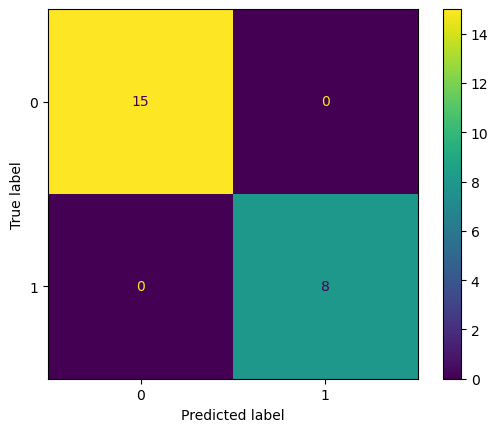

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds
)

plt.show()

#MIGHT BE DATA LEAKAGE

In [86]:
target_related = [
    "Essential hypertension (disorder)",
    "Hyperlipidemia (disorder)",
    "Chronic congestive heart failure (disorder)"
]

for col in target_related:
    print(col in X.columns)

True
True
True


In [88]:
target_cols = [
    "Essential hypertension (disorder)",
    "Hyperlipidemia (disorder)",
    "Chronic congestive heart failure (disorder)"
]

# Create target
mdf["TARGET"] = mdf[target_cols].max(axis=1).astype(int)

# Remove target-defining columns
mdf = mdf.drop(columns=target_cols)

KeyError: "None of [Index(['Essential hypertension (disorder)', 'Hyperlipidemia (disorder)',\n       'Chronic congestive heart failure (disorder)'],\n      dtype='object')] are in the [columns]"

In [89]:
for col in target_cols:
    print(col in mdf.columns)

False
False
False


In [90]:
y = mdf["TARGET"]
X = mdf.drop(columns=["TARGET"])

In [92]:
print(X.shape)
print(y.shape)

(111, 138)
(111,)


In [93]:
print(X[["GENDER", "RACE", "ETHNICITY"]].head())

  GENDER   RACE    ETHNICITY
0      F  white  nonhispanic
1      F  white  nonhispanic
2      F  white     hispanic
3      F  asian  nonhispanic
4      F  black  nonhispanic


In [94]:
X = pd.get_dummies(
    X,
    columns=["GENDER", "RACE", "ETHNICITY"],
    drop_first=True
)

print(X.shape)

(111, 141)


In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(88, 141)
(23, 141)


In [96]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

In [97]:
print("Train Missing:", X_train.isnull().sum().sum())
print("Test Missing :", X_test.isnull().sum().sum())

Train Missing: 0
Test Missing : 0


In [98]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

CatBoostClassifier(depth=5, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=0)

In [99]:
preds = model.predict(X_test)

pred_probs = model.predict_proba(X_test)[:, 1]

In [100]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall   :", recall_score(y_test, preds))
print("F1 Score :", f1_score(y_test, preds))
print("ROC AUC  :", roc_auc_score(y_test, pred_probs))

print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         8

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



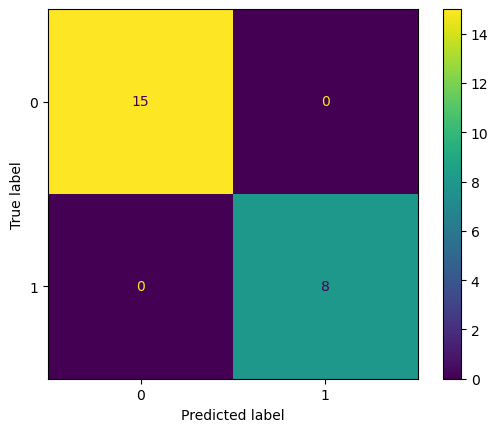

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds
)

plt.show()

In [102]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(30)

,Feature,Importance
82,lisinopril 10 MG Oral Tablet,26.289149
133,AVG_CREATININE,23.706123
50,Hydrochlorothiazide 25 MG Oral Tablet,10.703533
66,Simvastatin 10 MG Oral Tablet,8.442632
0,AGE,7.613947
134,LATEST_CREATININE,5.004760
119,AVG_DBP,2.725030
106,Gingivitis (disorder),1.532854
71,amLODIPine 2.5 MG Oral Tablet,1.307550
129,AVG_LDL,0.902532


In [103]:
med_cols = []

for col in X.columns:
    if (
        "Tablet" in col
        or "Injection" in col
        or "Capsule" in col
        or "MG" in col
        or "ML" in col
        or "Oral" in col
        or "Syringe" in col
    ):
        med_cols.append(col)

print(len(med_cols))

95


In [104]:
X_no_med = X.drop(columns=med_cols)

print(X_no_med.shape)

(111, 46)


In [106]:
X_no_med = X.drop(columns=med_cols)

print("Original Shape :", X.shape)
print("Without Medications :", X_no_med.shape)

Original Shape : (111, 141)
Without Medications : (111, 46)


In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_no_med,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(88, 46)
(23, 46)


In [108]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

In [109]:
print("Train Missing:", X_train.isnull().sum().sum())
print("Test Missing :", X_test.isnull().sum().sum())

Train Missing: 0
Test Missing : 0


In [110]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

CatBoostClassifier(depth=5, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=0)

In [111]:
preds = model.predict(X_test)

pred_probs = model.predict_proba(X_test)[:, 1]

In [112]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall   :", recall_score(y_test, preds))
print("F1 Score :", f1_score(y_test, preds))
print("ROC AUC  :", roc_auc_score(y_test, pred_probs))

print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Accuracy : 0.782608695652174
Precision: 1.0
Recall   : 0.375
F1 Score : 0.5454545454545454
ROC AUC  : 0.9416666666666668

Classification Report:

              precision    recall  f1-score   support

           0       0.75      1.00      0.86        15
           1       1.00      0.38      0.55         8

    accuracy                           0.78        23
   macro avg       0.88      0.69      0.70        23
weighted avg       0.84      0.78      0.75        23



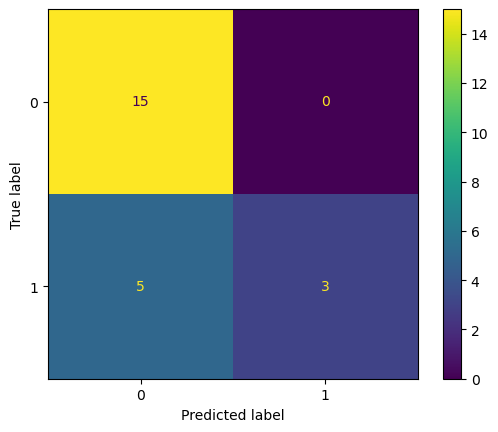

In [113]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds
)

plt.show()

In [114]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
38,AVG_CREATININE,25.349768
0,AGE,20.066045
24,AVG_DBP,8.171315
22,AVG_SBP,7.482952
28,AVG_GLUCOSE,6.299868
39,LATEST_CREATININE,6.010694
11,Gingivitis (disorder),2.897683
33,LATEST_CHOLESTEROL,2.688319
30,AVG_HBA1C,2.039063
35,LATEST_LDL,1.945672


In [115]:
feature_importance.head(20)[["Feature","Importance"]]

,Feature,Importance
38,AVG_CREATININE,25.349768
0,AGE,20.066045
24,AVG_DBP,8.171315
22,AVG_SBP,7.482952
28,AVG_GLUCOSE,6.299868
39,LATEST_CREATININE,6.010694
11,Gingivitis (disorder),2.897683
33,LATEST_CHOLESTEROL,2.688319
30,AVG_HBA1C,2.039063
35,LATEST_LDL,1.945672


#Let's see what happens at lower thresholds.

In [116]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    preds_t = (pred_probs >= t).astype(int)

    results.append([
        t,
        precision_score(y_test, preds_t, zero_division=0),
        recall_score(y_test, preds_t),
        f1_score(y_test, preds_t)
    ])

results = pd.DataFrame(
    results,
    columns=["Threshold","Precision","Recall","F1"]
)

results

,Threshold,Precision,Recall,F1
0,0.10,1.0,0.625,0.769231
1,0.15,1.0,0.500,0.666667
2,0.20,1.0,0.500,0.666667
3,0.25,1.0,0.500,0.666667
4,0.30,1.0,0.500,0.666667
5,0.35,1.0,0.500,0.666667
6,0.40,1.0,0.375,0.545455
7,0.45,1.0,0.375,0.545455
8,0.50,1.0,0.375,0.545455
9,0.55,1.0,0.375,0.545455


In [117]:
results.sort_values(
    by="F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
0,0.10,1.0,0.625,0.769231
1,0.15,1.0,0.500,0.666667
2,0.20,1.0,0.500,0.666667
3,0.25,1.0,0.500,0.666667
4,0.30,1.0,0.500,0.666667
5,0.35,1.0,0.500,0.666667
6,0.40,1.0,0.375,0.545455
7,0.45,1.0,0.375,0.545455
8,0.50,1.0,0.375,0.545455
9,0.55,1.0,0.375,0.545455


In [118]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
38,AVG_CREATININE,25.349768
0,AGE,20.066045
24,AVG_DBP,8.171315
22,AVG_SBP,7.482952
28,AVG_GLUCOSE,6.299868
39,LATEST_CREATININE,6.010694
11,Gingivitis (disorder),2.897683
33,LATEST_CHOLESTEROL,2.688319
30,AVG_HBA1C,2.039063
35,LATEST_LDL,1.945672


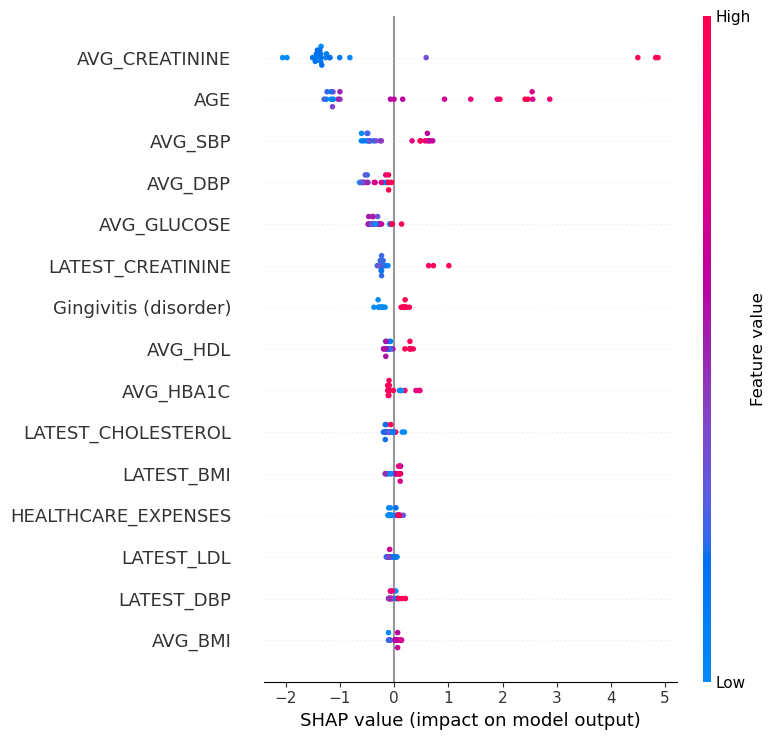

In [119]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    max_display=15
)

In [120]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train, y_train)

C:\Users\asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000, random_state=42)

In [121]:
lr_preds = lr_model.predict(X_test)

lr_probs = lr_model.predict_proba(X_test)[:, 1]

In [134]:
X_train.columns

Index(['AGE', 'INCOME', 'HEALTHCARE_EXPENSES', 'index',
       'Acute bacterial sinusitis (disorder)', 'Acute bronchitis (disorder)',
       'Acute infective cystitis (disorder)', 'Anemia (disorder)',
       'Awaiting transplantation of kidney (situation)',
       'Chronic obstructive bronchitis (disorder)',
       'Diabetes mellitus type 2 (disorder)', 'Gingivitis (disorder)',
       'History of renal transplant (situation)',
       'Osteoarthritis of hip (disorder)', 'Osteoarthritis of knee (disorder)',
       'Patient referral for dental care (procedure)', 'Prediabetes (finding)',
       'Sepsis (disorder)', 'Streptococcal sore throat (disorder)',
       'Viral sinusitis (disorder)', 'AVG_BMI', 'LATEST_BMI', 'AVG_SBP',
       'LATEST_SBP', 'AVG_DBP', 'LATEST_DBP', 'AVG_HR', 'LATEST_HR',
       'AVG_GLUCOSE', 'LATEST_GLUCOSE', 'AVG_HBA1C', 'LATEST_HBA1C',
       'AVG_CHOLESTEROL', 'LATEST_CHOLESTEROL', 'AVG_LDL', 'LATEST_LDL',
       'AVG_HDL', 'LATEST_HDL', 'AVG_CREATININE', 'LATEST

In [122]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, lr_preds))
print("Precision:", precision_score(y_test, lr_preds))
print("Recall   :", recall_score(y_test, lr_preds))
print("F1 Score :", f1_score(y_test, lr_preds))
print("ROC AUC  :", roc_auc_score(y_test, lr_probs))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_preds))

Accuracy : 0.8260869565217391
Precision: 0.8333333333333334
Recall   : 0.625
F1 Score : 0.7142857142857143
ROC AUC  : 0.9083333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.93      0.88        15
           1       0.83      0.62      0.71         8

    accuracy                           0.83        23
   macro avg       0.83      0.78      0.79        23
weighted avg       0.83      0.83      0.82        23



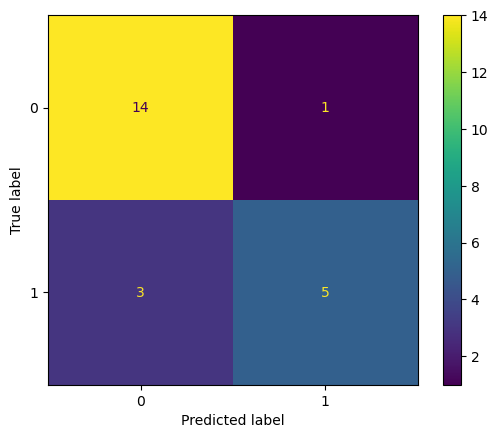

In [123]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_preds
)

plt.show()

In [124]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient
34,AVG_LDL,0.377255
24,AVG_DBP,0.331040
39,LATEST_CREATININE,0.297077
38,AVG_CREATININE,0.288571
0,AGE,0.220060
40,GENDER_M,0.191486
22,AVG_SBP,0.165445
37,LATEST_HDL,0.163590
20,AVG_BMI,0.150328
29,LATEST_GLUCOSE,0.128307


In [125]:
coef_df.tail(15)

,Feature,Coefficient
4,Acute bacterial sinusitis (disorder),-0.011607
23,LATEST_SBP,-0.018916
33,LATEST_CHOLESTEROL,-0.022121
44,RACE_white,-0.023554
3,index,-0.030049
43,RACE_other,-0.030258
13,Osteoarthritis of hip (disorder),-0.033886
18,Streptococcal sore throat (disorder),-0.034423
28,AVG_GLUCOSE,-0.046669
35,LATEST_LDL,-0.073985


In [126]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    preds_t = (lr_probs >= t).astype(int)

    results.append([
        t,
        precision_score(y_test, preds_t, zero_division=0),
        recall_score(y_test, preds_t),
        f1_score(y_test, preds_t)
    ])

results = pd.DataFrame(
    results,
    columns=["Threshold","Precision","Recall","F1"]
)

results.sort_values(
    by="F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
10,0.60,1.000000,0.625,0.769231
11,0.65,1.000000,0.625,0.769231
6,0.40,0.833333,0.625,0.714286
7,0.45,0.833333,0.625,0.714286
8,0.50,0.833333,0.625,0.714286
9,0.55,0.833333,0.625,0.714286
0,0.10,0.666667,0.750,0.705882
1,0.15,0.666667,0.750,0.705882
4,0.30,0.714286,0.625,0.666667
5,0.35,0.714286,0.625,0.666667


# Random Forest

In [128]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]

In [129]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall   :", recall_score(y_test, rf_preds))
print("F1 Score :", f1_score(y_test, rf_preds))
print("ROC AUC  :", roc_auc_score(y_test, rf_probs))

Accuracy : 0.782608695652174
Precision: 1.0
Recall   : 0.375
F1 Score : 0.5454545454545454
ROC AUC  : 0.9750000000000001


In [138]:
drop_cols = [
    # medication columns
    c for c in X.columns
    if (
        "MG" in c
        or "Tablet" in c
        or "Injection" in c
        or "Capsule" in c
        or "Inhaler" in c
        or "Oral" in c
        or "Solution" in c
    )
]

# disease columns
disease_cols = [
    "Acute bacterial sinusitis (disorder)",
    "Acute bronchitis (disorder)",
    "Acute infective cystitis (disorder)",
    "Anemia (disorder)",
    "Awaiting transplantation of kidney (situation)",
    "Chronic obstructive bronchitis (disorder)",
    "Diabetes mellitus type 2 (disorder)",
    "Gingivitis (disorder)",
    "History of renal transplant (situation)",
    "Osteoarthritis of hip (disorder)",
    "Osteoarthritis of knee (disorder)",
    "Patient referral for dental care (procedure)",
    "Prediabetes (finding)",
    "Sepsis (disorder)",
    "Streptococcal sore throat (disorder)",
    "Viral sinusitis (disorder)"
]

X_clean = X.drop(
    columns=drop_cols + disease_cols,
    errors="ignore"
)

print(X_clean.shape)

(111, 31)


In [139]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

y = mdf["TARGET"]
X = X_clean

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train, y_train)

C:\Users\asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000, random_state=42)

In [140]:
from sklearn.metrics import *

preds = lr_model.predict(X_test)
probs = lr_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,preds))
print("Precision:", precision_score(y_test,preds))
print("Recall   :", recall_score(y_test,preds))
print("F1 Score :", f1_score(y_test,preds))
print("ROC AUC  :", roc_auc_score(y_test,probs))

Accuracy : 0.8260869565217391
Precision: 1.0
Recall   : 0.5
F1 Score : 0.6666666666666666
ROC AUC  : 0.9083333333333333


In [141]:
print(X_clean.columns.tolist())

['AGE', 'INCOME', 'HEALTHCARE_EXPENSES', 'insulin isophane  human 70 UNT/ML / insulin  regular  human 30 UNT/ML Injectable Suspension [Humulin]', 'index', 'AVG_BMI', 'LATEST_BMI', 'AVG_SBP', 'LATEST_SBP', 'AVG_DBP', 'LATEST_DBP', 'AVG_HR', 'LATEST_HR', 'AVG_GLUCOSE', 'LATEST_GLUCOSE', 'AVG_HBA1C', 'LATEST_HBA1C', 'AVG_CHOLESTEROL', 'LATEST_CHOLESTEROL', 'AVG_LDL', 'LATEST_LDL', 'AVG_HDL', 'LATEST_HDL', 'AVG_CREATININE', 'LATEST_CREATININE', 'GENDER_M', 'RACE_black', 'RACE_hawaiian', 'RACE_other', 'RACE_white', 'ETHNICITY_nonhispanic']


In [142]:
X_clean = X_clean.drop(
    columns=[
        "insulin isophane  human 70 UNT/ML / insulin  regular  human 30 UNT/ML Injectable Suspension [Humulin]",
        "index"
    ],
    errors="ignore"
)

print(X_clean.shape)

(111, 29)


In [143]:
y = mdf["TARGET"]
X = X_clean

In [144]:
# ==========================================
# FINAL MODEL TRAINING PIPELINE
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# ------------------------------------------
# Define X and y
# ------------------------------------------

y = mdf["TARGET"]

X = X_clean.copy()

# ------------------------------------------
# Train-Test Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ------------------------------------------
# Missing Value Imputation
# ------------------------------------------

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

# ------------------------------------------
# Logistic Regression
# ------------------------------------------

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train, y_train)

# ------------------------------------------
# Predictions
# ------------------------------------------

preds = lr_model.predict(X_test)

probs = lr_model.predict_proba(X_test)[:, 1]

# ------------------------------------------
# Evaluation
# ------------------------------------------

print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall   :", recall_score(y_test, preds))
print("F1 Score :", f1_score(y_test, preds))
print("ROC AUC  :", roc_auc_score(y_test, probs))

print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Accuracy : 0.7391304347826086
Precision: 0.6666666666666666
Recall   : 0.5
F1 Score : 0.5714285714285714
ROC AUC  : 0.9083333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.87      0.81        15
           1       0.67      0.50      0.57         8

    accuracy                           0.74        23
   macro avg       0.72      0.68      0.69        23
weighted avg       0.73      0.74      0.73        23



C:\Users\asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [145]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import joblib

# Use all data
X_final = X_clean.copy()
y_final = mdf["TARGET"]

# Impute
imputer = SimpleImputer(strategy="median")

X_final = pd.DataFrame(
    imputer.fit_transform(X_final),
    columns=X_final.columns
)

# Train
final_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

final_model.fit(X_final, y_final)

# Save
joblib.dump(final_model, "cardio_risk_model.pkl")
joblib.dump(imputer, "imputer.pkl")
joblib.dump(X_final.columns.tolist(), "feature_names.pkl")

print("Deployment model saved!")

Deployment model saved!


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
